In [1]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# import cupy as np   

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

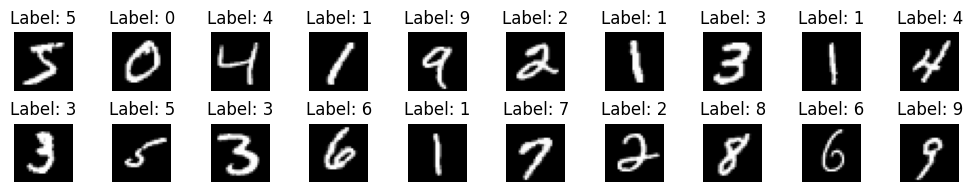

In [2]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
train_eval_loader = DataLoader(dataset=train_dataset, batch_size=1000, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

def show_samples(dataset, n=20):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


In [3]:
# Numpy 2-layer NN trained on MNIST (mini-batch SGD)
np.random.seed(0)
torch.manual_seed(0)

def init_params(hidden_size=128):
    W1 = np.random.randn(hidden_size, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(10, hidden_size) * np.sqrt(2 / hidden_size)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    # stable softmax
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y, num_classes=10):
    Y = Y.astype(int)
    one_hot_Y = np.zeros((num_classes, Y.size), dtype=np.float64)
    one_hot_Y[Y, np.arange(Y.size)] = 1.0
    return one_hot_Y

def backward_prop(Z1, A1, A2, W1, W2, X, one_hot_Y, lambd):
    m = X.shape[1]
    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * dZ2.dot(A1.T) + (lambd / m) * W2
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T) + (lambd / m) * W1
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    return W1, b1, W2, b2

def get_predictions(A2):
    return np.argmax(A2, axis=0)

def accuracy_from_logits(A2, Y):
    preds = get_predictions(A2)
    return float(np.mean(preds == Y))

def evaluate_loader(W1, b1, W2, b2, loader):
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.detach().cpu()
        labels = labels.detach().cpu()
        X = images.view(images.size(0), -1).numpy().T  # (784, batch)
        Y = labels.numpy()
        _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
        preds = get_predictions(A2)
        correct += int(np.sum(preds == Y))
        total += Y.size
    return correct / total


def cross_entropy_loss_from_probs(A2, Y, eps=1e-12):
    """Cross-entropy loss given softmax probabilities A2 and labels Y."""
    m = Y.size
    # A2: (num_classes, batch)
    probs = A2[Y, np.arange(m)]
    return float(-np.mean(np.log(probs + eps)))


def evaluate_loader_loss(W1, b1, W2, b2, loader):
    total_loss = 0.0
    total = 0
    for images, labels in loader:
        images = images.detach().cpu()
        labels = labels.detach().cpu()
        X = images.view(images.size(0), -1).numpy().T  # (784, batch)
        Y = labels.numpy()
        _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
        loss = cross_entropy_loss_from_probs(A2, Y)
        total_loss += loss * Y.size
        total += Y.size
    return total_loss / total


def train_sgd(train_loader, alpha=0.1, epochs=5, lambd=0.0, hidden_size=128):
    W1, b1, W2, b2 = init_params(hidden_size)

    history = {
        "train_acc": [],
        "test_acc": [],
        "train_loss": [],
        "test_loss": [],
    }

    # Metrics before any training updates (epoch 0)
    train_acc = evaluate_loader(W1, b1, W2, b2, train_eval_loader)
    test_acc = evaluate_loader(W1, b1, W2, b2, test_loader)
    train_loss = evaluate_loader_loss(W1, b1, W2, b2, train_eval_loader)
    test_loss = evaluate_loader_loss(W1, b1, W2, b2, test_loader)

    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Epoch 0/{epochs} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

    for epoch in range(1, epochs + 1):
        for images, labels in train_loader:
            images = images.detach().cpu()
            labels = labels.detach().cpu()
            X = images.view(images.size(0), -1).numpy().T
            Y = labels.numpy()
            oh = one_hot(Y, num_classes=10)

            Z1, A1, _, A2 = forward_prop(W1, b1, W2, b2, X)
            dW1, db1, dW2, db2 = backward_prop(Z1, A1, A2, W1, W2, X, oh, lambd)
            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        train_acc = evaluate_loader(W1, b1, W2, b2, train_eval_loader)
        test_acc = evaluate_loader(W1, b1, W2, b2, test_loader)
        train_loss = evaluate_loader_loss(W1, b1, W2, b2, train_eval_loader)
        test_loss = evaluate_loader_loss(W1, b1, W2, b2, test_loader)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(f"Epoch {epoch}/{epochs} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

    return W1, b1, W2, b2, history


# Train on MNIST
W1, b1, W2, b2, history = train_sgd(train_loader, alpha=0.1, epochs=5, lambd=0.0, hidden_size=128)


Epoch 0/5 | train acc: 0.1557 | test acc: 0.1505
Epoch 1/5 | train acc: 0.9632 | test acc: 0.9579
Epoch 2/5 | train acc: 0.9795 | test acc: 0.9701
Epoch 3/5 | train acc: 0.9842 | test acc: 0.9727
Epoch 4/5 | train acc: 0.9879 | test acc: 0.9764
Epoch 5/5 | train acc: 0.9909 | test acc: 0.9777


In [ ]:
# Plot loss & accuracy curves
epochs = np.arange(len(history["train_acc"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["test_loss"], label="test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="train acc")
axes[1].plot(epochs, history["test_acc"], label="test acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [4]:
# Final evaluation on full MNIST train/test sets
train_acc = evaluate_loader(W1, b1, W2, b2, train_eval_loader)
test_acc = evaluate_loader(W1, b1, W2, b2, test_loader)
print(f"Final train accuracy: {train_acc:.4f}")
print(f"Final test accuracy : {test_acc:.4f}")


Final train accuracy: 0.9909
Final test accuracy : 0.9777


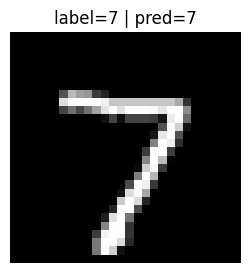

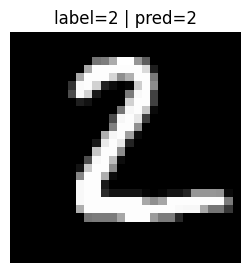

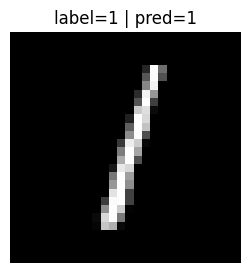

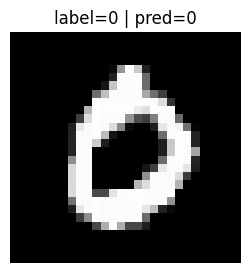

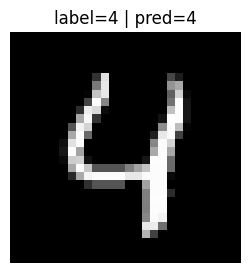

In [5]:
# Single-image prediction helper (uses the same normalization as the dataset)

def predict_proba_single(image_tensor_1x28x28, W1, b1, W2, b2):
    img = image_tensor_1x28x28.detach().cpu()
    X = img.view(-1, 1).numpy()  # (784, 1)
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    return A2[:, 0]

def show_prediction(dataset, index, W1, b1, W2, b2):
    img, label = dataset[index]  # img is normalized tensor
    probs = predict_proba_single(img, W1, b1, W2, b2)
    pred = int(np.argmax(probs))

    plt.figure(figsize=(3, 3))
    plt.imshow(dataset.data[index].numpy(), cmap='gray')  # raw pixels for display
    plt.title(f"label={int(label)} | pred={pred}")
    plt.axis('off')
    plt.show()

for idx in [0, 1, 2, 3, 4]:
    show_prediction(test_dataset, idx, W1, b1, W2, b2)


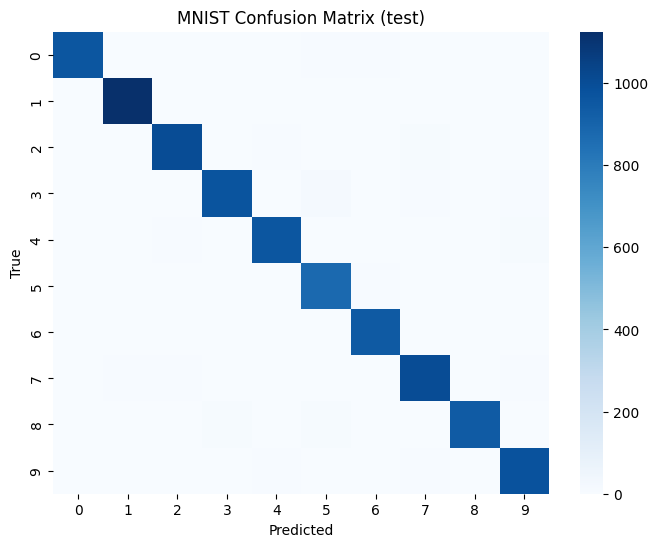

In [6]:
# Confusion matrix on MNIST test set

def confusion_matrix_loader(W1, b1, W2, b2, loader, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for images, labels in loader:
        images = images.detach().cpu()
        labels = labels.detach().cpu()
        X = images.view(images.size(0), -1).numpy().T
        Y = labels.numpy()
        _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
        preds = get_predictions(A2)
        for y, p in zip(Y, preds):
            cm[int(y), int(p)] += 1
    return cm

cm = confusion_matrix_loader(W1, b1, W2, b2, test_loader)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MNIST Confusion Matrix (test)')
plt.show()


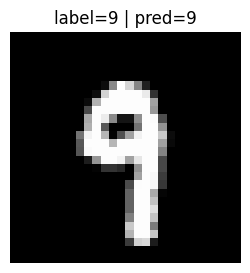

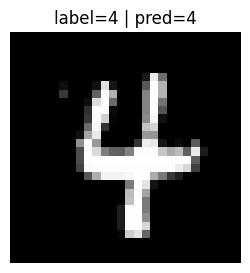

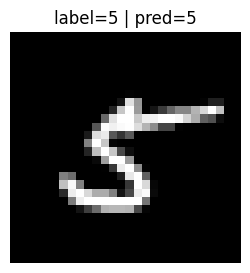

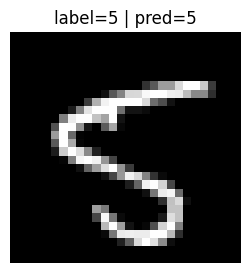

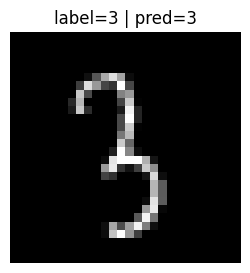

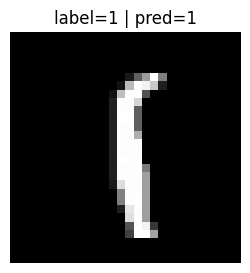

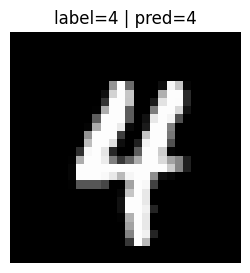

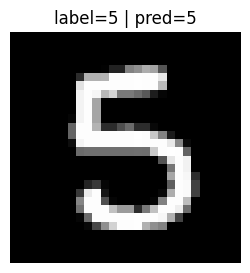

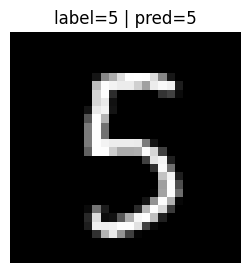

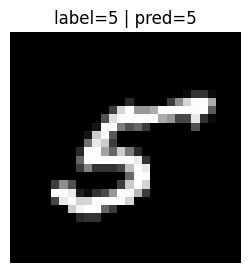

In [7]:
# Show a few random test predictions
rng = np.random.default_rng(0)
indices = rng.integers(low=0, high=len(test_dataset), size=10)

for idx in indices:
    show_prediction(test_dataset, int(idx), W1, b1, W2, b2)
